In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from network_idx.eda.correlations import fetch_data_from_bq

from google.cloud import bigquery
from network_idx.config import GCS_PROJECT_ID, NETWORK_IDX_ENV, GCS_ADC_JSON_PATH_EP_LOCAL
from network_idx.utils import check_and_authenticate

In [2]:
# Fetch data from bq
tract_df = fetch_data_from_bq()

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [3]:
# Modify tract_df to create new features and drop unnecessary columns
tract_df_modified = tract_df.copy()
techs = ['copper','cable','fiber']
for tech in techs:
    tract_df_modified[f'{tech}_speed_100_to_sub_gig'] = tract_df_modified[f"{tech}_speed_100_20_only"].add(tract_df_modified[f"{tech}_speed_250_25_only"], fill_value=0)

# tract_df_modified['perc_growth_parcels'] = round(tract_df_modified['growth_parcels'] / tract_df_modified['total_parcels'], 2)

cols_to_drop = [
    'copper_speed_less_than_100_20',
    'copper_speed_100_20_only',
    'copper_speed_250_25_only',
    'cable_speed_less_than_100_20',
    'cable_speed_100_20_only',
    'cable_speed_250_25_only',
    'fiber_speed_less_than_100_20',
    'fiber_speed_100_20_only',
    'fiber_speed_250_25_only',
    'fiber_speed_equal_greater_than_100_20',
    'copper_max_upload_speed',
    #'cable_max_upload_speed',
    #'fiber_max_upload_speed',
    'total_parcels',
    'growth_parcels',
    'unique_locations',
    'total_flags',
    'flags_minus_greatest',
    'new_clip_count',
    'parcel_split_count',
    'mean_dist_nearest_hotspot_m',
    'mean_dist_nearest_fiber_m'
    ]

tract_df_modified = tract_df_modified.drop(columns=cols_to_drop)
tract_df_modified.info()

<class 'pandas.DataFrame'>
RangeIndex: 85481 entries, 0 to 85480
Data columns (total 30 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   tract_geoid                     85481 non-null  str    
 1   pop_ch_1yr                      84178 non-null  float64
 2   pop_ch_avg                      84178 non-null  float64
 3   pop_pctch_1yr                   84169 non-null  float64
 4   pop_pctch_avg                   84170 non-null  float64
 5   estimated_census_housing_units  85481 non-null  int64  
 6   estimated_fcc_units             85481 non-null  int64  
 7   copper_speed_1000_100_only      85481 non-null  float64
 8   cable_speed_1000_100_only       85481 non-null  float64
 9   fiber_speed_1000_100_only       85481 non-null  float64
 10  cable_location_count            84909 non-null  float64
 11  cable_provider_count            82151 non-null  float64
 12  cable_max_download_speed        82151 non-n

##### Binary Features for Growth

In [4]:
# Create binary indicators for growth features using percentile thresholds
binary_features_p90 = [
    'pre_early_dev_parcels',
    'landuse_change_count',
    'builder_developer_count',
    'building_permit_count'
    ]

# P90 threshold for landuse, builder, permits
for col in binary_features_p90:
    threshold = tract_df_modified[col].quantile(0.90)
    tract_df_modified[f'{col}_bin'] = (tract_df_modified[col] >= threshold).astype(int)
    print(f"{col}: P90 threshold = {threshold}, bin=1 count = {tract_df_modified[f'{col}_bin'].sum()}")


# Drop raw count columns (replaced by binary)
# NOTE: Keeping these variables for the clustering step
# tract_df_modified = tract_df_modified.drop(columns=['pre_early_dev_parcels'] + binary_features_p90)


# Examine df
tract_df_modified.info()

pre_early_dev_parcels: P90 threshold = 43.0, bin=1 count = 8591
landuse_change_count: P90 threshold = 8.0, bin=1 count = 8533
builder_developer_count: P90 threshold = 9.0, bin=1 count = 8708
building_permit_count: P90 threshold = 7.0, bin=1 count = 8724
<class 'pandas.DataFrame'>
RangeIndex: 85481 entries, 0 to 85480
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   tract_geoid                     85481 non-null  str    
 1   pop_ch_1yr                      84178 non-null  float64
 2   pop_ch_avg                      84178 non-null  float64
 3   pop_pctch_1yr                   84169 non-null  float64
 4   pop_pctch_avg                   84170 non-null  float64
 5   estimated_census_housing_units  85481 non-null  int64  
 6   estimated_fcc_units             85481 non-null  int64  
 7   copper_speed_1000_100_only      85481 non-null  float64
 8   cable_speed_1000_100_only       8

##### Examining Distance to Fiber Lines

In [6]:
# Examine percentile values
print(f"{tract_df_modified['median_dist_nearest_fiber_m'].describe().round(2).to_string()}")
print(f"90th Percentile: {tract_df_modified['median_dist_nearest_fiber_m'].quantile(0.9):.2f}")
print(f"95th Percentile: {tract_df_modified['median_dist_nearest_fiber_m'].quantile(0.95):.2f}")
print(f"99th Percentile: {tract_df_modified['median_dist_nearest_fiber_m'].quantile(0.99):.2f}")
print(f"99.5th Percentile: {tract_df_modified['median_dist_nearest_fiber_m'].quantile(0.995):.2f}")

count    82849.00
mean      1865.37
std       3644.43
min          0.02
25%        216.85
50%        506.57
75%       1539.66
max      24136.45
90th Percentile: 5054.14
95th Percentile: 9466.97
99th Percentile: 19984.76
99.5th Percentile: 21979.93


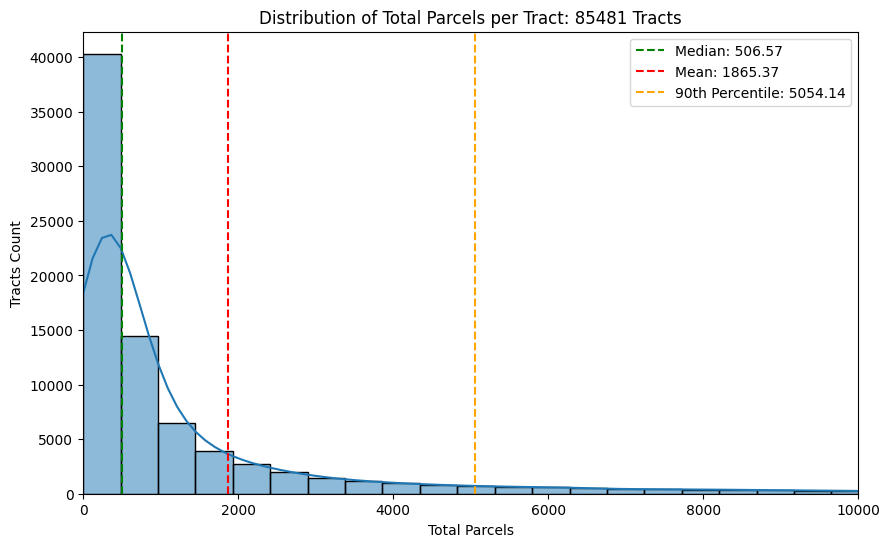

In [8]:
# Draw histrogram of growth_col
col = 'median_dist_nearest_fiber_m'
plt.figure(figsize=(10,6))
#data = tract_df[tract_df_modified[col] <= 400][growth_col]
sns.histplot(tract_df_modified[col], bins=50, kde=True)
plt.axvline(tract_df_modified[col].median(), color='green', linestyle='--', label=f'Median: {tract_df_modified[col].median():.2f}')
plt.axvline(tract_df_modified[col].mean(), color='red', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.2f}')
plt.axvline(tract_df_modified[col].quantile(0.90), color='orange', linestyle='--', label=f'90th Percentile: {tract_df_modified[col].quantile(0.9):.2f}')
plt.legend()
plt.title(f"Distribution of Total Parcels per Tract: {tract_df_modified.shape[0]} Tracts")
plt.xlabel("Total Parcels")
plt.ylabel("Tracts Count")
plt.xlim(0, 10000)  # Focus on the range with most data
plt.show()

##### Examine and Treat NAs

In [5]:
# Check for NA values for population change and population change %
print("NA values in population change:", tract_df_modified['pop_ch_1yr'].isna().sum())
print("NA values in population change %:", tract_df_modified['pop_pctch_1yr'].isna().sum())


NA values in population change: 1303
NA values in population change %: 1312


Estimated Census Housing Units Summary:
count    85481.00
mean      1751.00
std        802.43
min          0.00
25%       1235.00
50%       1662.00
75%       2165.00
max      16688.00
Census tracts with zero housing units: 694
Census tracts with 1-50 housing units: 554
Census tracts with 51-100 housing units: 70


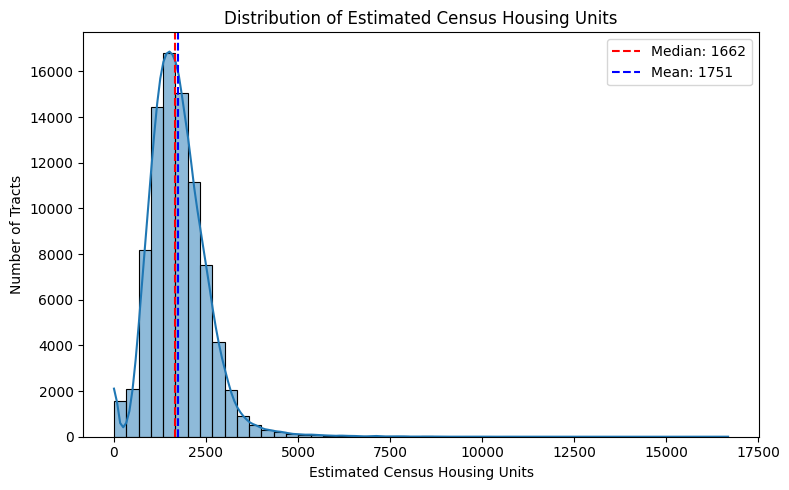

In [6]:
# Checking distribution of housing units
# print summary stats for housing units first
print(f"Estimated Census Housing Units Summary:")
print(tract_df_modified['estimated_census_housing_units'].describe().round(2).to_string())
print("="*80)

# Census tracts with zero housing units
print(f"Census tracts with zero housing units: {(tract_df_modified['estimated_census_housing_units'] == 0).sum()}")
print("="*80)

# Census tracts with 1-50 housing units
print(f"Census tracts with 1-50 housing units: {(tract_df_modified['estimated_census_housing_units'] > 0).sum() - (tract_df_modified['estimated_census_housing_units'] >= 50).sum()}")
print("="*80)

# Census tracts with 51-100 housing units
print(f"Census tracts with 51-100 housing units: {(tract_df_modified['estimated_census_housing_units'] > 50).sum() - (tract_df_modified['estimated_census_housing_units'] >= 100).sum()}")
print("="*80)

plt.figure(figsize=(8, 5))
sns.histplot(tract_df_modified['estimated_census_housing_units'], bins=50, kde=True)
plt.title('Distribution of Estimated Census Housing Units')
plt.xlabel('Estimated Census Housing Units')
plt.ylabel('Number of Tracts')
plt.axvline(tract_df_modified['estimated_census_housing_units'].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified["estimated_census_housing_units"].median():.0f}')
plt.axvline(tract_df_modified['estimated_census_housing_units'].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified["estimated_census_housing_units"].mean():.0f}')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
# Check the state breakdown of tracts with < 50 housing units
zero_hh_tracts = tract_df_modified.loc[tract_df_modified['estimated_census_housing_units'] <50, ['tract_geoid']]
zero_hh_tracts['state_fips'] = zero_hh_tracts['tract_geoid'].str[:2]
print("State breakdown of tracts with < 50 housing units:")
print(zero_hh_tracts['state_fips'].value_counts())

State breakdown of tracts with < 50 housing units:
state_fips
36    171
26    128
06     98
12     96
48     71
72     62
42     53
15     40
51     40
04     34
37     34
25     33
47     25
22     24
34     22
39     21
24     20
08     19
55     19
45     19
53     16
13     15
09     15
18     14
35     14
20     13
17     12
21     10
28     10
40     10
32      9
41      9
01      8
29      8
49      7
23      7
27      7
10      6
19      5
44      4
33      3
31      3
05      3
11      3
02      2
30      2
16      1
54      1
50      1
56      1
Name: count, dtype: int64


**Key Takeaway:** These tracts seem to be water bodies, so we will exclude them from analysis

In [8]:
# Filter tracts with NA values for population change and population change %
# TODO: investigate why these are NA values when other values exist
tract_df_modified = tract_df_modified.dropna(subset=['pop_ch_1yr', 'pop_pctch_1yr'])
print(f"After dropping NA values for population change features: {len(tract_df_modified)} rows remaining")

# Filter for census tracts with at least 50 housing units to avoid skew from very small tracts
housing_unit_threshold = 50
tract_df_modified = tract_df_modified[tract_df_modified['estimated_census_housing_units'] >= housing_unit_threshold]
print(f"After dropping NA values for HH features: {len(tract_df_modified)} rows remaining")
tract_df_modified.info()

After dropping NA values for population change features: 84169 rows remaining
After dropping NA values for HH features: 83313 rows remaining
<class 'pandas.DataFrame'>
Index: 83313 entries, 0 to 85480
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   tract_geoid                     83313 non-null  str    
 1   pop_ch_1yr                      83313 non-null  float64
 2   pop_ch_avg                      83313 non-null  float64
 3   pop_pctch_1yr                   83313 non-null  float64
 4   pop_pctch_avg                   83313 non-null  float64
 5   estimated_census_housing_units  83313 non-null  int64  
 6   estimated_fcc_units             83313 non-null  int64  
 7   copper_speed_1000_100_only      83313 non-null  float64
 8   cable_speed_1000_100_only       83313 non-null  float64
 9   fiber_speed_1000_100_only       83313 non-null  float64
 10  cable_location_count         

#### EDA for FCC metrics: Distributions and Feature Engineering
##### <u>Table 1 (Advertised Speeds):</u> Provider Counts

In [9]:
# Examine nulls and zeroes for provider counts
technologies = ['copper', 'cable', 'fiber']
for tech in technologies:
    print("=" * 80)
    print(f"{tech} provider count nulls: {tract_df_modified[f'{tech}_provider_count'].isna().sum()}")
    print(f"{tech} provider count zeroes: {(tract_df_modified[f'{tech}_provider_count'] == 0).sum()}")

copper provider count nulls: 15862
copper provider count zeroes: 0
cable provider count nulls: 2693
cable provider count zeroes: 0
fiber provider count nulls: 2606
fiber provider count zeroes: 0


In [10]:
# Set provider counts to zero where null (assuming null means no providers)
for tech in technologies:
    tract_df_modified[f'{tech}_provider_count'] = tract_df_modified[f'{tech}_provider_count'].fillna(0).astype(int)
    print("=" * 80)
    print(f"{tech} provider count nulls: {tract_df_modified[f'{tech}_provider_count'].isna().sum()}")
    print(f"{tech} provider count zeroes: {(tract_df_modified[f'{tech}_provider_count'] == 0).sum()}")

copper provider count nulls: 0
copper provider count zeroes: 15862
cable provider count nulls: 0
cable provider count zeroes: 2693
fiber provider count nulls: 0
fiber provider count zeroes: 2606


       copper_provider_count  cable_provider_count  fiber_provider_count
count               83313.00              83313.00              83313.00
mean                    1.03                  1.18                  2.53
std                     0.70                  0.50                  1.30
min                     0.00                  0.00                  0.00
25%                     1.00                  1.00                  2.00
50%                     1.00                  1.00                  2.00
75%                     1.00                  1.00                  3.00
max                     6.00                  5.00                 14.00


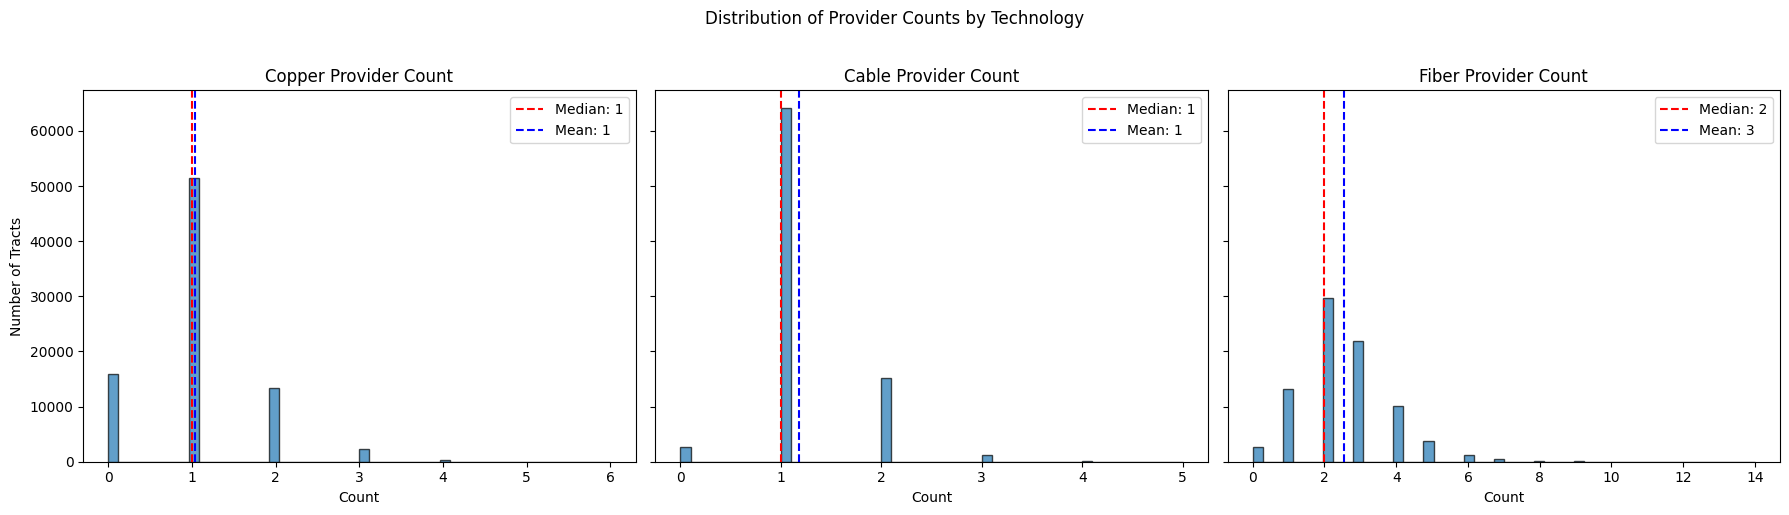

In [11]:
# Distribution of provider counts by technology
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, tech in zip(axes, ['copper', 'cable', 'fiber']):
    col = f'{tech}_provider_count'
    ax.hist(tract_df_modified[col], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(tract_df_modified[col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[col].median():.0f}')
    ax.axvline(tract_df_modified[col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.0f}')
    ax.set_title(f'{tech.title()} Provider Count')
    ax.set_xlabel('Count')
    ax.legend()

axes[0].set_ylabel('Number of Tracts')
plt.suptitle('Distribution of Provider Counts by Technology', y=1.02)
plt.tight_layout()

# Summary stats side by side
loc_cols = [f'{t}_provider_count' for t in ['copper', 'cable', 'fiber']]
print(tract_df_modified[loc_cols].describe().round(2).to_string())

In [12]:
# Examine specific values for provider counts
for tech in technologies:
    print("=" * 80)
    print(f"{tech} provider count=1 (Monopoly): {(tract_df_modified[f'{tech}_provider_count'] == 1).sum()}")
    print(f"{tech} provider count=2 (Duopoly): {(tract_df_modified[f'{tech}_provider_count'] == 2).sum()}")
    print(f"{tech} provider count=3 (...): {(tract_df_modified[f'{tech}_provider_count'] == 3).sum()}")
    print(f"{tech} provider count>3: {(tract_df_modified[f'{tech}_provider_count'] > 3).sum()}")
    

copper provider count=1 (Monopoly): 51537
copper provider count=2 (Duopoly): 13401
copper provider count=3 (...): 2257
copper provider count>3: 256
cable provider count=1 (Monopoly): 64162
cable provider count=2 (Duopoly): 15108
cable provider count=3 (...): 1275
cable provider count>3: 75
fiber provider count=1 (Monopoly): 13162
fiber provider count=2 (Duopoly): 29631
fiber provider count=3 (...): 21948
fiber provider count>3: 15966


In [13]:
# Areas with different provider counts by technology
# While counting zeroes, also check cases where values are null. For example, if fiber_provider_count is null but copper_provider_count is 0, we should count that as zero fiber providers rather than excluding it from the analysis.

# Everything is zero
print("=" * 80)
print(f"No providers (copper, cable, fiber all zero): {int(((tract_df_modified['copper_provider_count'] == 0) & (tract_df_modified['cable_provider_count'] == 0) & (tract_df_modified['fiber_provider_count'] == 0)).sum())}")

# Copper but no cable or fiber (copper > 0, cable=0, fiber=0)
print("=" * 80)
print(f"Copper but no cable or fiber: {int((((tract_df_modified['copper_provider_count'] > 0) & (tract_df_modified['cable_provider_count'] == 0)) & (tract_df_modified['fiber_provider_count'] == 0)).sum())}")

# No fiber but cable (fiber=0, cable>0)
print("=" * 80)
print(f"Cable but no fiber: {int(((tract_df_modified['cable_provider_count'] > 0) & (tract_df_modified['fiber_provider_count'] == 0)).sum())}")

# Any cable and 1 fiber
print("=" * 80)
print(f"Any cable and 1 fiber: {int(((tract_df_modified['cable_provider_count'] >= 0) & (tract_df_modified['fiber_provider_count'] == 1)).sum())}")

# Any cable and 2 fiber
print("=" * 80)
print(f"Any cable and 2 fiber: {int(((tract_df_modified['cable_provider_count'] >= 0) & (tract_df_modified['fiber_provider_count'] == 2)).sum())}")

# Any cable and 3 fiber
print("=" * 80)
print(f"Any cable and 3 fiber: {int(((tract_df_modified['cable_provider_count'] >= 0) & (tract_df_modified['fiber_provider_count'] == 3)).sum())}")

# Any cable and 3+ fiber
print("=" * 80)
print(f"Any cable and 3+ fiber: {int(((tract_df_modified['cable_provider_count'] >= 0) & (tract_df_modified['fiber_provider_count'] > 3)).sum())}")

No providers (copper, cable, fiber all zero): 75
Copper but no cable or fiber: 216
Cable but no fiber: 2315
Any cable and 1 fiber: 13162
Any cable and 2 fiber: 29631
Any cable and 3 fiber: 21948
Any cable and 3+ fiber: 15966


In [14]:
# Tracts percentage tracts with fiber that have/don't have cable
print("=" * 80)
tracts_with_fiber = tract_df_modified[tract_df_modified['fiber_provider_count'] > 0].shape[0]
fiber_with_cable = tract_df_modified[(tract_df_modified['fiber_provider_count'] > 0) & (tract_df_modified['cable_provider_count'] > 0)].shape[0]
fiber_without_cable = tract_df_modified[(tract_df_modified['fiber_provider_count'] > 0) & (tract_df_modified['cable_provider_count'] == 0)].shape[0]
print(f"Tracts with fiber: {tracts_with_fiber}")
print(f"Tracts with fiber but not cable: {fiber_without_cable} ({fiber_without_cable / tract_df_modified.shape[0] * 100:.2f}%)") 

Tracts with fiber: 80707
Tracts with fiber but not cable: 2402 (2.88%)


In [15]:
# Similar analysis but reversed
print("=" * 80)
tracts_with_cable = tract_df_modified[tract_df_modified['cable_provider_count'] > 0].shape[0]
cable_with_fiber = tract_df_modified[(tract_df_modified['cable_provider_count'] > 0) & (tract_df_modified['fiber_provider_count'] > 0)].shape[0]
cable_without_fiber = tract_df_modified[(tract_df_modified['cable_provider_count'] > 0) & (tract_df_modified['fiber_provider_count'] == 0)].shape[0]
print(f"Tracts with cable: {tracts_with_cable}")
print(f"Tracts with cable but not fiber: {cable_without_fiber} ({cable_without_fiber / tract_df_modified.shape[0] * 100:.2f})")

Tracts with cable: 80620
Tracts with cable but not fiber: 2315 (2.78)


**Key Takeaway:** Cable and fiber go hand in-hand. Their presence would be highly correlated. The reason we didn't catch this before is because we were checking correlation between number of providers, which don't have to correlate. Fiber tends to have higher number of providers than cable

In [16]:
# Add fiber density calculation
tract_df_modified['fiber_provider_density_per_1000_hhs'] = tract_df_modified['fiber_provider_count'] / tract_df_modified['estimated_census_housing_units'] * 1000
print(f"Fiber provider density per 1000 housing units summary:")
print(tract_df_modified['fiber_provider_density_per_1000_hhs'].describe().round(2).to_string())

Fiber provider density per 1000 housing units summary:
count    83313.00
mean         1.65
std          1.58
min          0.00
25%          0.94
50%          1.41
75%          2.04
max        159.42


In [17]:
# For fiber density, examine 90th, 95th, 99th percentiles to understand distribution and identify outliers
fiber_density_col = 'fiber_provider_density_per_1000_hhs'
print("=" * 80)
print(f"Fiber provider density per 1000 households stats:")
print(f"90th percentile: {tract_df_modified[fiber_density_col].quantile(0.90):.2f}")
print(f"95th percentile: {tract_df_modified[fiber_density_col].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_modified[fiber_density_col].quantile(0.99):.2f}")
print(f"99.5th percentile: {tract_df_modified[fiber_density_col].quantile(0.995):.2f}")
print(f"99.9th percentile: {tract_df_modified[fiber_density_col].quantile(0.999):.2f}")

Fiber provider density per 1000 households stats:
90th percentile: 2.88
95th percentile: 3.54
99th percentile: 5.55
99.5th percentile: 6.85
99.9th percentile: 15.34


Log(1 + Fiber provider density per 1000 households) stats:
count    83313.00
mean         0.90
std          0.37
min          0.00
25%          0.66
50%          0.88
75%          1.11
max          5.08
90th percentile: 1.36
95th percentile: 1.51
99th percentile: 1.88
99.5th percentile: 2.06


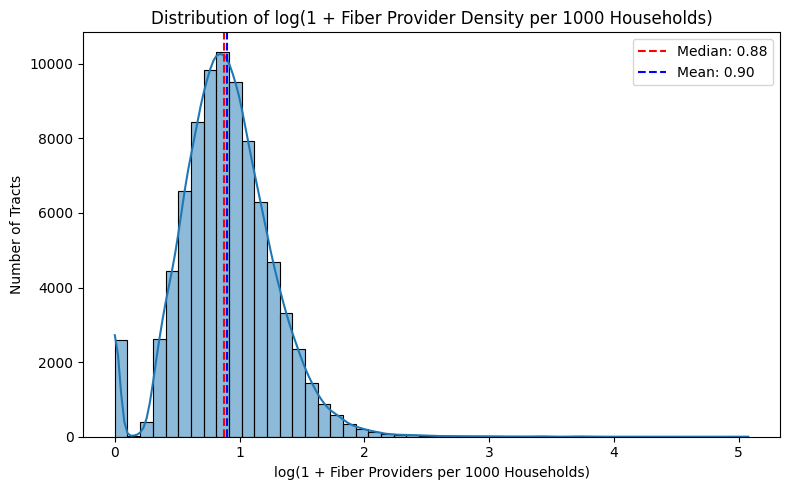

In [18]:
# For fiber, examine log(1+ provider density) to see if it normalizes distribution
tract_df_modified['log1p_fiber_provider_density_per_1000_hhs'] = np.log1p(tract_df_modified['fiber_provider_density_per_1000_hhs'])
# Check summary stats for log-transformed fiber density
print("=" * 80)
print("Log(1 + Fiber provider density per 1000 households) stats:")
print(tract_df_modified['log1p_fiber_provider_density_per_1000_hhs'].describe().round(2).to_string())
log_fiber_density_col = 'log1p_fiber_provider_density_per_1000_hhs'
print(f"90th percentile: {tract_df_modified[log_fiber_density_col].quantile(0.90):.2f}")
print(f"95th percentile: {tract_df_modified[log_fiber_density_col].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_modified[log_fiber_density_col].quantile(0.99):.2f}")
print(f"99.5th percentile: {tract_df_modified[log_fiber_density_col].quantile(0.995):.2f}")
print("=" * 80)
plt.figure(figsize=(8, 5))
sns.histplot(tract_df_modified[log_fiber_density_col], bins=50, kde=True)
plt.title('Distribution of log(1 + Fiber Provider Density per 1000 Households)')
plt.xlabel('log(1 + Fiber Providers per 1000 Households)')
plt.ylabel('Number of Tracts')
plt.axvline(tract_df_modified[log_fiber_density_col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[log_fiber_density_col].median():.2f}')
plt.axvline(tract_df_modified[log_fiber_density_col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[log_fiber_density_col].mean():.2f}')
plt.legend()
plt.tight_layout()
plt.show()

**Key Takeaways:** 
1. log transform is not necessarily needed because it still has this long tail which may differentiate our clusters
2. Anything more than 3 can be assumed to be a signal of saturation, so we can just cap this variable at 3 instead
3. Either way, this feature will likely be correlated with providers and housing_units given it is constructed from those two, so we will not use it in index formation. We can provide it as an attribute though. And for that, we don't have to cap it.   

**New features to build:**
1. Instead of copper and cable provider count: use binary indicators:
    * copper_present
    * cable_present
2. competitive_landscape, defined as:
* greenfield: 0 fiber, 0 cable ~ these would be 2192 census tracts
* cable_heavy: 0 fiber, 1+ cable ~2.3K tracts
* fiber_entry: any cable, 1 fiber ~ 12.4K tracts
* fiber_duopoly: any cable, 2 fiber ~ 29K tracts
* fiber_competitive: any cable, 3 fiber ~ 22K tracts
* fiber_satured: any cable, 3+ fiber ~ 16.2 tracts

3. provider_density, just for fiber as:
* (num_providers / estimated_census_units)*100 capped at 3
* Decision is to not create this right now, we can add it in post-processing using Cotality address counts as denominator

In [19]:
# Columns to add
tract_df_modified['copper_provider_present'] = (tract_df_modified['copper_provider_count'] > 0).astype(int)
tract_df_modified['cable_provider_present'] = (tract_df_modified['cable_provider_count'] > 0).astype(int)

# Check distribution of binary columns
print("Copper provider present distribution:")
print(tract_df_modified['copper_provider_present'].value_counts())
print("Cable provider present distribution:")
print(tract_df_modified['cable_provider_present'].value_counts()) 


def provider_competitive_landscape(row):
    if row['copper_provider_count'] == 0 and row['cable_provider_count'] == 0 and row['fiber_provider_count'] == 0:
        return 'no_providers'
    elif row['copper_provider_count'] > 0 and row['cable_provider_count'] == 0 and row['fiber_provider_count'] == 0:
        return 'greenfield'
    elif row['cable_provider_count'] > 0 and row['fiber_provider_count'] == 0:
        return 'cable_but_no_fiber'
    elif row['fiber_provider_count'] == 1:
        return 'fiber_entry'
    elif row['fiber_provider_count'] == 2:
        return 'fiber_duopoly'
    elif row['fiber_provider_count'] == 3:
        return 'fiber_competitive'
    elif row['fiber_provider_count'] > 3:
        return 'fiber_saturated'
    else:
        return 'Other'
# Apply the function to create the new column
tract_df_modified['provider_competitive_landscape'] = tract_df_modified.apply(provider_competitive_landscape, axis=1)

# Check distribution of new column
print("Distribution of provider competitive landscape:")
print(tract_df_modified['provider_competitive_landscape'].value_counts())

# Add provider density for fiber, capped at 3 providers per 1000 households to avoid outliers dominating the analysis
tract_df_modified['fiber_provider_density_per_1000_hhs_capped'] = tract_df_modified['fiber_provider_density_per_1000_hhs'].clip(upper=3)
print(f"Fiber provider density per 1000 households (capped at 3) summary:")
print(tract_df_modified['fiber_provider_density_per_1000_hhs_capped'].describe().round(2).to_string())

Copper provider present distribution:
copper_provider_present
1    67451
0    15862
Name: count, dtype: int64
Cable provider present distribution:
cable_provider_present
1    80620
0     2693
Name: count, dtype: int64
Distribution of provider competitive landscape:
provider_competitive_landscape
fiber_duopoly         29631
fiber_competitive     21948
fiber_saturated       15966
fiber_entry           13162
cable_but_no_fiber     2315
greenfield              216
no_providers             75
Name: count, dtype: int64
Fiber provider density per 1000 households (capped at 3) summary:
count    83313.00
mean         1.53
std          0.79
min          0.00
25%          0.94
50%          1.41
75%          2.04
max          3.00


##### <u>Table 1 (Advertised Speeds):</u> Location Counts

       copper_location_count  cable_location_count  fiber_location_count
count                84909.0               84909.0               84909.0
mean                   539.4                1123.7                 800.5
std                    575.5                 707.7                 702.9
min                      0.0                   0.0                   0.0
25%                     12.0                 626.0                 192.0
50%                    365.0                1089.0                 694.0
75%                    914.0                1556.0                1233.0
max                   6778.0               14383.0               14335.0


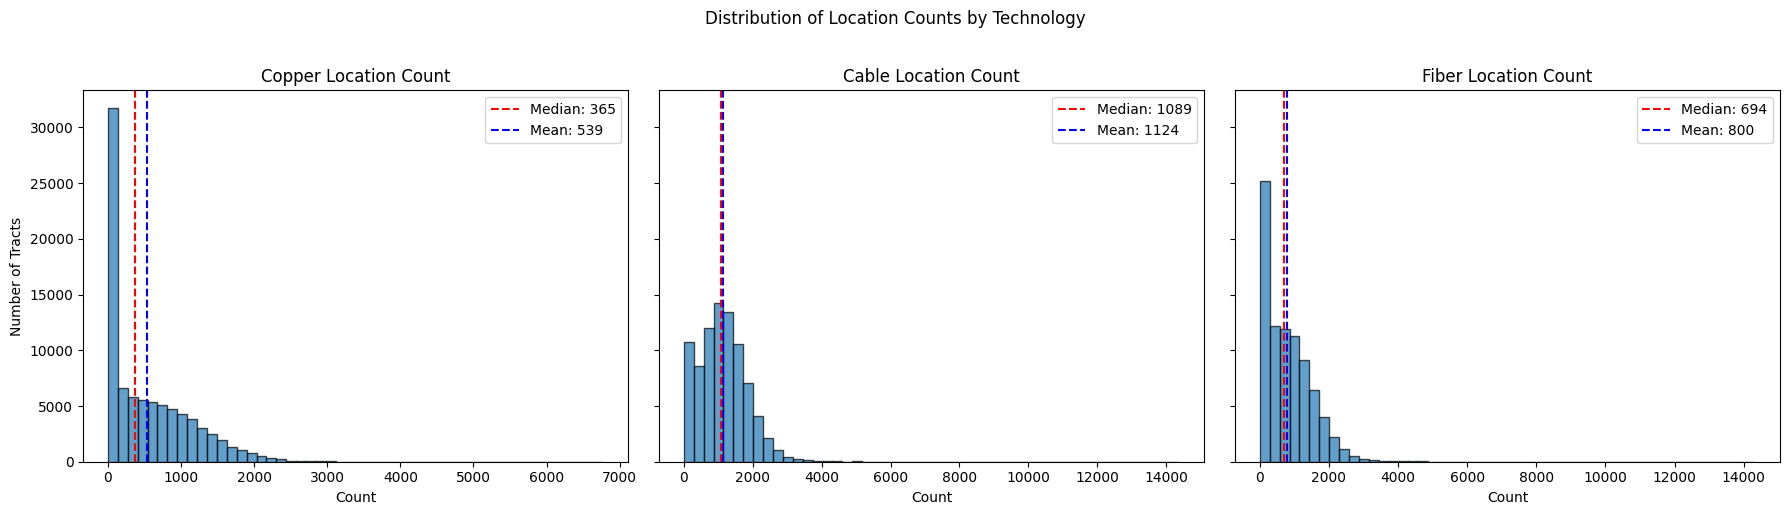

In [14]:
# Distribution of location counts by technology
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, tech in zip(axes, ['copper', 'cable', 'fiber']):
    col = f'{tech}_location_count'
    ax.hist(tract_df_modified[col], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(tract_df_modified[col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[col].median():.0f}')
    ax.axvline(tract_df_modified[col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.0f}')
    ax.set_title(f'{tech.title()} Location Count')
    ax.set_xlabel('Count')
    ax.legend()

axes[0].set_ylabel('Number of Tracts')
plt.suptitle('Distribution of Location Counts by Technology', y=1.02)
plt.tight_layout()


# Summary stats side by side
loc_cols = [f'{t}_location_count' for t in ['copper', 'cable', 'fiber']]
print(tract_df_modified[loc_cols].describe().round(1).to_string())

In [12]:
# Check location_count = 0 for fiber
print(f"Number of tracts with zero fiber locations: {len(tract_df_modified[tract_df_modified['fiber_location_count'] == 0])}")

Number of tracts with zero fiber locations: 2715


**Potentially new features to explore:**
1. fiber_penetration: fiber_location_count / estimated_census_housing_units
2. cable_penetration: same as above but for cable. In the definition in the final schema, this should have "deployment_viability" next to it 
3. fiber_opportunity_gap: (housing_units - fiber_location) / housing_units
5. Interaction term: fiber_opportunity_gap * cable_penetration

In [21]:
# Calculate cable penetration
tract_df_modified['cable_penetration'] = tract_df_modified['cable_location_count'] / tract_df_modified['estimated_census_housing_units']
print("=" * 80)
print("Cable penetration stats:")
print(tract_df_modified['cable_penetration'].describe().round(2).to_string())

# Calculate fiber penetration
tract_df_modified['fiber_penetration'] = tract_df_modified['fiber_location_count'] / tract_df_modified['estimated_census_housing_units']
print("=" * 80)
print("Fiber penetration stats:")
print(tract_df_modified['fiber_penetration'].describe().round(2).to_string())

# Fiber opportunity gap
tract_df_modified['fiber_opportunity_gap'] = (tract_df_modified['estimated_census_housing_units'] - tract_df_modified['fiber_location_count']) / tract_df_modified['estimated_census_housing_units']
print("=" * 80)
print("Fiber opportunity gap stats:")
print(tract_df_modified['fiber_opportunity_gap'].describe().round(2).to_string())

# Interaction term: fiber_opportunity_gap * cable_penetration
# TODO: Interaction term could be additive too - fiber_opportunity_gap + cable_penetration
tract_df_modified['fiber_cable_interaction'] = tract_df_modified['fiber_opportunity_gap'] * tract_df_modified['cable_penetration']
print("=" * 80)
print("Fiber-Cable Interaction Term stats:")
print(tract_df_modified['fiber_cable_interaction'].describe().round(4).to_string())

Cable penetration stats:
count    83238.00
mean         0.65
std          0.31
min          0.00
25%          0.45
50%          0.72
75%          0.89
max          5.19
Fiber penetration stats:
count    83238.00
mean         0.46
std          0.35
min          0.00
25%          0.13
50%          0.46
75%          0.76
max          5.78
Fiber opportunity gap stats:
count    83238.00
mean         0.54
std          0.35
min         -4.78
25%          0.24
50%          0.54
75%          0.87
max          1.00
Fiber-Cable Interaction Term stats:
count    83238.0000
mean         0.3227
std          0.3028
min        -22.0831
25%          0.1252
50%          0.2516
75%          0.4752
max          1.8348


In [22]:
# Quadrant analysis: fiber opportunity gap vs cable penetration
# Filter to [0,1] range for both
plot_df = tract_df_modified[
    (tract_df_modified['fiber_opportunity_gap'].between(0, 1)) &
    (tract_df_modified['cable_penetration'].between(0, 1))
].copy()

# Assign quadrants
conditions = [
    (plot_df['cable_penetration'] < 0.5) & (plot_df['fiber_opportunity_gap'] >= 0.5),  # Low cable, High gap
    (plot_df['cable_penetration'] >= 0.5) & (plot_df['fiber_opportunity_gap'] >= 0.5), # High cable, High gap
    (plot_df['cable_penetration'] < 0.5) & (plot_df['fiber_opportunity_gap'] < 0.5),   # Low cable, Low gap
    (plot_df['cable_penetration'] >= 0.5) & (plot_df['fiber_opportunity_gap'] < 0.5),  # High cable, Low gap
]
labels = ['Low Cable / High Gap', 'High Cable / High Gap', 'Low Cable / Low Gap', 'High Cable / Low Gap']
plot_df['quadrant'] = np.select(conditions, labels, default='Unknown')

# Quadrant summary
quadrant_summary = plot_df['quadrant'].value_counts()
quadrant_pct = (quadrant_summary / len(plot_df) * 100).round(1)
print("Quadrant Counts and Percentages:")
print(pd.DataFrame({'count': quadrant_summary, 'pct': quadrant_pct}))

Quadrant Counts and Percentages:
                       count   pct
quadrant                          
High Cable / Low Gap   28440  38.0
High Cable / High Gap  24287  32.5
Low Cable / High Gap   17911  23.9
Low Cable / Low Gap     4164   5.6


In [23]:
# Check correlation of interaction term with constituent features
correlation_matrix = plot_df[['fiber_opportunity_gap', 'cable_penetration', 'fiber_cable_interaction']].corr().round(2)
print("Correlation Matrix:")
print(correlation_matrix.to_string())

Correlation Matrix:
                         fiber_opportunity_gap  cable_penetration  fiber_cable_interaction
fiber_opportunity_gap                     1.00              -0.32                     0.62
cable_penetration                        -0.32               1.00                     0.45
fiber_cable_interaction                   0.62               0.45                     1.00


**Key Takeaways:**
Final Metrics to add based on location_counts raw data:
1. cable_penetration: cable_location_counts / housing_units --> this is deployment viability
2. fiber_opportunity_gap: (housing_units - fiber_location) / housing_units
3. Interaction term: fiber_opportunity_gap * cable_penetration

**NOTES:**
1. Decided to drop copper_location_counts because it is legacy technology but should validate this.
2. Interaction term quadrants + formula (addition instead of multiplication) needs be explored 

##### <u>Table 1 (Advertised Speeds):</u> Advertised Speeds

       copper_max_download_speed  cable_max_download_speed  fiber_max_download_speed
count                    68752.0                   82151.0                   82194.0
mean                       114.7                    1464.2                    9684.0
std                        143.3                     501.8                   47422.1
min                          0.0                       0.0                       0.0
25%                         75.0                    1000.0                    2000.0
50%                        100.0                    1200.0                    5000.0
75%                        100.0                    2000.0                   10000.0
max                       6000.0                    5000.0                10000000.0


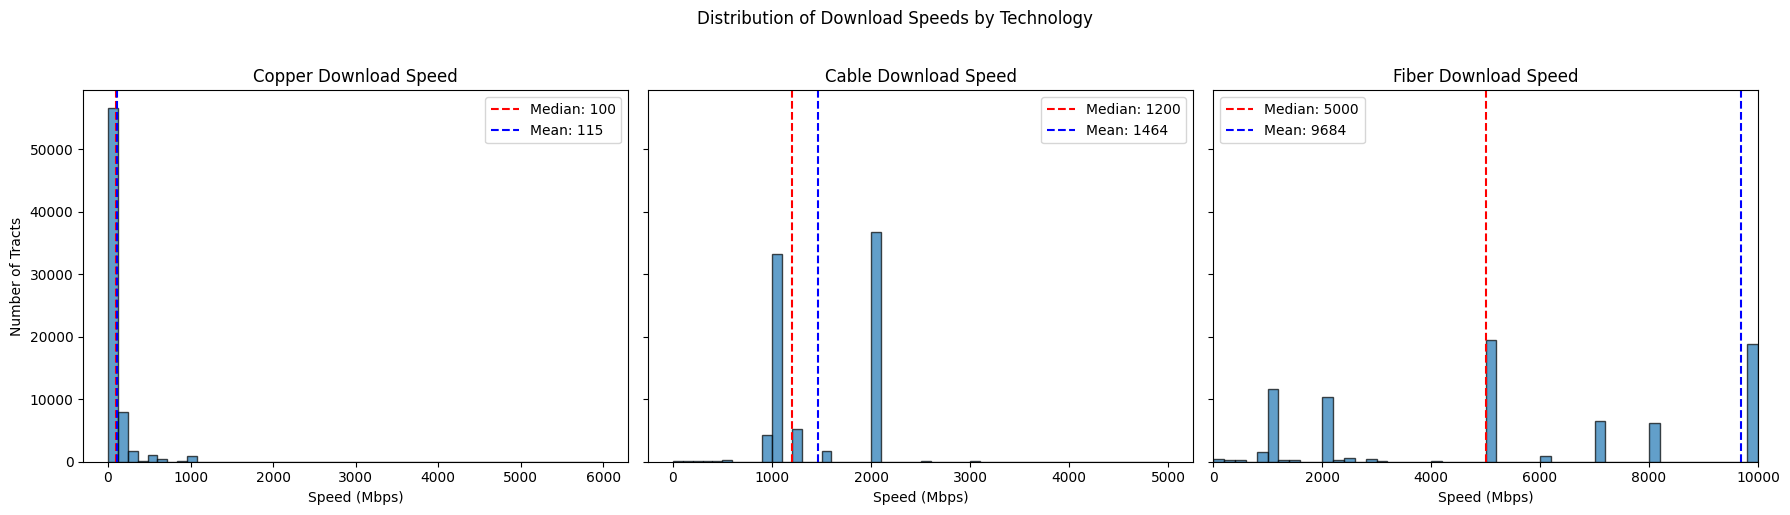

In [19]:
# Distribution of download speeds by technology
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

fiber_p95 = tract_df_modified['fiber_max_download_speed'].quantile(0.95)

for ax, tech in zip(axes, ['copper', 'cable', 'fiber']):
    col = f'{tech}_max_download_speed'
    data = tract_df_modified[tract_df_modified[col] <= fiber_p95][col] if tech == 'fiber' else tract_df_modified[col]
    ax.hist(data, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(tract_df_modified[col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[col].median():.0f}')
    ax.axvline(tract_df_modified[col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.0f}')
    ax.set_title(f'{tech.title()} Download Speed')
    ax.set_xlabel('Speed (Mbps)')
    ax.legend()

axes[0].set_ylabel('Number of Tracts')
axes[2].set_xlim(0, fiber_p95)
plt.suptitle('Distribution of Download Speeds by Technology', y=1.02)
plt.tight_layout()

# Summary stats side by side
loc_cols = [f'{t}_max_download_speed' for t in ['copper', 'cable', 'fiber']]
print(tract_df_modified[loc_cols].describe().round(1).to_string())

       cable_max_upload_speed  fiber_max_upload_speed
count                 80620.0                 80707.0
mean                    250.1                  9662.0
std                     425.7                 47637.9
min                       0.0                     0.0
25%                      35.0                  2000.0
50%                     100.0                  5000.0
75%                     250.0                 10000.0
max                    5000.0              10000000.0


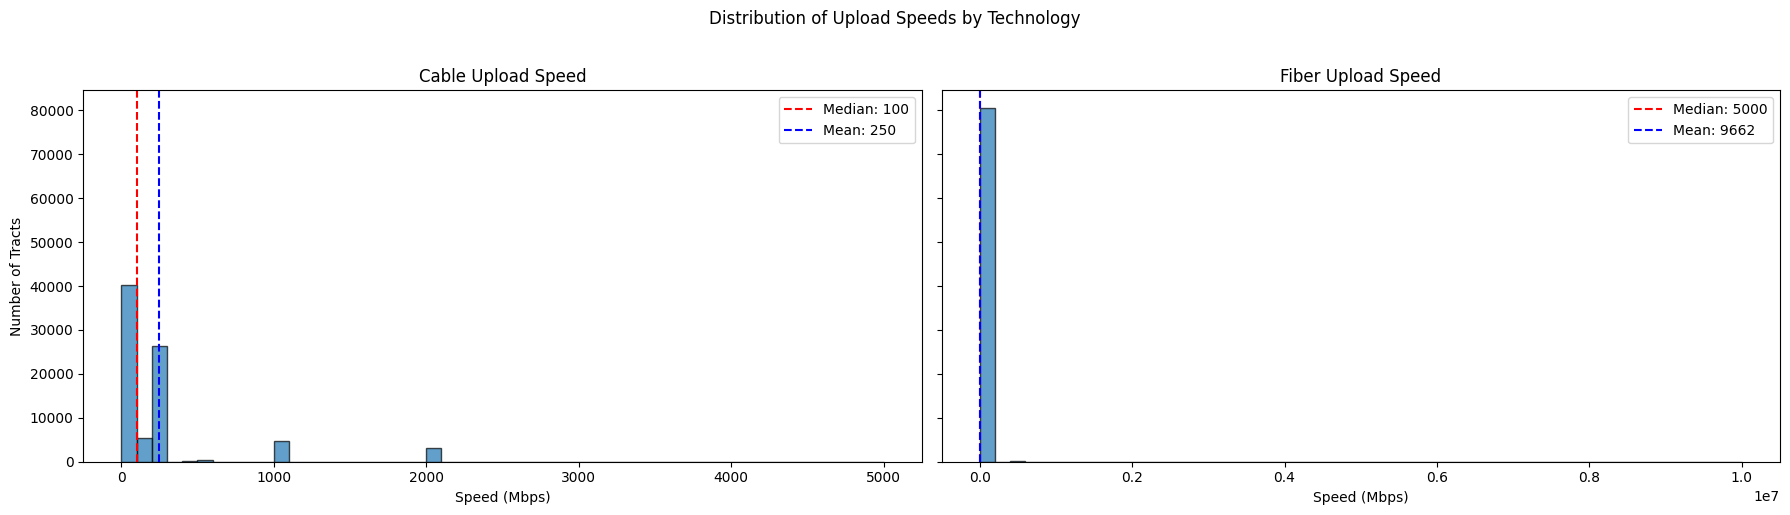

In [25]:
# Same analysis as above but for upload speeds
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

for ax, tech in zip(axes, ['cable', 'fiber']):
    col = f'{tech}_max_upload_speed'
    ax.hist(tract_df_modified[col], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(tract_df_modified[col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[col].median():.0f}')
    ax.axvline(tract_df_modified[col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.0f}')
    ax.set_title(f'{tech.title()} Upload Speed')
    ax.set_xlabel('Speed (Mbps)')
    ax.legend()

axes[0].set_ylabel('Number of Tracts')
plt.suptitle('Distribution of Upload Speeds by Technology', y=1.02)
plt.tight_layout()

# Summary stats side by side
loc_cols = [f'{t}_max_upload_speed' for t in ['cable', 'fiber']]
print(tract_df_modified[loc_cols].describe().round(1).to_string())

In [26]:
# fiber speeds has outliers, so checking 90th, 95th, 99th percentiles to understand distribution and identify outliers
print(f"90th percentile: {tract_df_modified['fiber_max_download_speed'].quantile(0.90):.2f}")
print(f"95th percentile: {tract_df_modified['fiber_max_download_speed'].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_modified['fiber_max_download_speed'].quantile(0.99):.2f}")
print(f"99.9th percentile: {tract_df_modified['fiber_max_download_speed'].quantile(0.999):.2f}")

90th percentile: 10000.00
95th percentile: 10000.00
99th percentile: 100000.00
99.9th percentile: 400000.00


In [27]:
# Same check as above but for upload speeds
print(f"90th percentile: {tract_df_modified['fiber_max_upload_speed'].quantile(0.90):.2f}")
print(f"95th percentile: {tract_df_modified['fiber_max_upload_speed'].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_modified['fiber_max_upload_speed'].quantile(0.99):.2f}")
print(f"99.9th percentile: {tract_df_modified['fiber_max_upload_speed'].quantile(0.999):.2f}")

90th percentile: 10000.00
95th percentile: 10000.00
99th percentile: 100000.00
99.9th percentile: 400000.00


In [28]:
# Checking tracts where current speed thresholds of 1 Gbps download and 100 Mbps upload are not met for cable and fiber
# For cable
cable_below_threshold = tract_df_modified[
    (tract_df_modified['cable_max_download_speed'] < 1000) | 
    (tract_df_modified['cable_max_upload_speed'] < 100)
]
print(f"Cable: Tracts below 1 Gbps download or 100 Mbps upload: {len(cable_below_threshold)} ({len(cable_below_threshold) / len(tract_df_modified) * 100:.2f}%)")

# Fiber speeds for tracts below cable thresholds to see if fiber is meeting demand in these areas
cable_below_threshold_fiber_speeds = cable_below_threshold['fiber_max_download_speed'].describe().round(1).to_string()
print(f"Fiber download speeds for tracts below cable thresholds:\n{cable_below_threshold_fiber_speeds}")

# For fiber
fiber_below_threshold = tract_df_modified[
    (tract_df_modified['fiber_max_download_speed'] < 1000) | 
    (tract_df_modified['fiber_max_upload_speed'] < 100)
]
print(f"Fiber: Tracts below 1 Gbps download or 100 Mbps upload: {len(fiber_below_threshold)} ({len(fiber_below_threshold) / len(tract_df_modified) * 100:.2f}%)")

# For below threshold fiber tracts, examine typical cable speeds to see if demand is met by cable in these areas
fiber_below_threshold_cable_speeds = fiber_below_threshold['cable_max_download_speed'].describe().round(1).to_string()
print(f"Cable download speeds for tracts below fiber thresholds:\n{fiber_below_threshold_cable_speeds}")

Cable: Tracts below 1 Gbps download or 100 Mbps upload: 40180 (48.23%)
Fiber download speeds for tracts below cable thresholds:
count      39146.0
mean        8368.4
std        20318.4
min            0.0
25%         2000.0
50%         5000.0
75%        10000.0
max      1200000.0
Fiber: Tracts below 1 Gbps download or 100 Mbps upload: 3262 (3.92%)
Cable download speeds for tracts below fiber thresholds:
count    3198.0
mean     1702.7
std       473.3
min         0.0
25%      1200.0
50%      2000.0
75%      2000.0
max      3000.0


In [29]:
# Both cable and fiber
both_below_threshold = tract_df_modified[
    ((tract_df_modified['cable_max_download_speed'] < 1000) & (tract_df_modified['fiber_max_download_speed'] < 1000)) |
    ((tract_df_modified['cable_max_upload_speed'] < 100) & (tract_df_modified['fiber_max_upload_speed'] < 100))
]
print(f"Cable and Fiber: Tracts below 1 Gbps download or 100 Mbps upload: {len(both_below_threshold)} ({len(both_below_threshold) / len(tract_df_modified) * 100:.2f}%)")

# For these tracts where both cable and fiber are bad, check number of providers for each
both_below_threshold_provider_counts = both_below_threshold[['cable_provider_count', 'fiber_provider_count']].describe().round(1).to_string()
print(f"Provider counts for tracts below thresholds for both cable and fiber:\n{both_below_threshold_provider_counts}")

# For tracts where both cable and fiber are bad, check estimated housing units
both_below_threshold_housing_units = both_below_threshold['estimated_census_housing_units'].describe().round(1).to_string()
print(f"Housing units for tracts below thresholds for both cable and fiber:\n{both_below_threshold_housing_units}")

# For tracts where both cable and fiber are bad, check population change to see if these are declining areas
both_below_threshold_population_change = both_below_threshold['pop_pctch_1yr'].describe().round(1).to_string()
print(f"Population % change for tracts below thresholds for both cable and fiber:\n{both_below_threshold_population_change}")

Cable and Fiber: Tracts below 1 Gbps download or 100 Mbps upload: 853 (1.02%)
Provider counts for tracts below thresholds for both cable and fiber:
       cable_provider_count  fiber_provider_count
count                 853.0                 853.0
mean                    1.1                   1.1
std                     0.4                   0.3
min                     1.0                   1.0
25%                     1.0                   1.0
50%                     1.0                   1.0
75%                     1.0                   1.0
max                     3.0                   3.0
Housing units for tracts below thresholds for both cable and fiber:
count     853.0
mean     1540.7
std       633.2
min       188.0
25%      1095.0
50%      1488.0
75%      1912.0
max      5979.0
Population % change for tracts below thresholds for both cable and fiber:
count    853.0
mean       0.8
std        1.0
min       -5.5
25%        0.3
50%        0.7
75%        1.2
max        8.3


##### DONOT INCLUDE BINARY FEATURES FOR ADVERTISED SPEEDS

In [ ]:
# NOTE: Cancelled this because signals are captured by % unit table feature
# NOTE: And data in that table is more reliable than "advertised speeds"
# Add new binary features: we can check correlation with features from the % unit table later
# Binary: cable advertised speed below 1 Gbps download OR 100 Mbps upload
tract_df_modified['cable_adv_speed_below_1000_100'] = (
    (tract_df_modified['cable_max_download_speed'] < 1000) |
    (tract_df_modified['cable_max_upload_speed'] < 100)
).astype(int)

# Binary: fiber advertised speed below 1 Gbps download OR 100 Mbps upload
tract_df_modified['fiber_adv_speed_below_1000_100'] = (
    (tract_df_modified['fiber_max_download_speed'] < 1000) |
    (tract_df_modified['fiber_max_upload_speed'] < 100)
).astype(int)

# Binary: both technologies below threshold (download AND upload checked independently)
tract_df_modified['cable_fiber_adv_speed_below_1000_100'] = (
    ((tract_df_modified['cable_max_download_speed'] < 1000) & (tract_df_modified['fiber_max_download_speed'] < 1000)) |
    ((tract_df_modified['cable_max_upload_speed'] < 100) & (tract_df_modified['fiber_max_upload_speed'] < 100))
).astype(int)

# Check distributions
for col in ['cable_adv_speed_below_1000_100', 'fiber_adv_speed_below_1000_100', 'cable_fiber_adv_speed_below_1000_100']:
    print(f"{tract_df_modified[col].value_counts()}\n")

cable_adv_speed_below_1000_100
0    43133
1    40180
Name: count, dtype: int64

fiber_adv_speed_below_1000_100
0    80051
1     3262
Name: count, dtype: int64

cable_fiber_adv_speed_below_1000_100
0    82460
1      853
Name: count, dtype: int64



**Key Ideas for speeds:**
1. Copper speeds are restrictive from a physics perspective. For a network idx, they won't have any meaning. Exclude this feature
2. Cable speed distribution is much tigher; fiber speeds fluctuate a lot
3. These binary features are OK for now; we can examine correlation with % residential units table later on and keep one of the two

##### <u>Table 2 (Fixed Summary by Geography):</u> Percentage Units Covered

       copper_speed_100_to_sub_gig  cable_speed_100_to_sub_gig  fiber_speed_100_to_sub_gig
count                    83313.000                   83313.000                   83313.000
mean                         0.042                       0.548                       0.063
std                          0.064                       0.344                       0.169
min                          0.000                       0.000                       0.000
25%                          0.000                       0.230                       0.000
50%                          0.010                       0.620                       0.000
75%                          0.070                       0.890                       0.020
max                          0.920                       1.000                       0.990


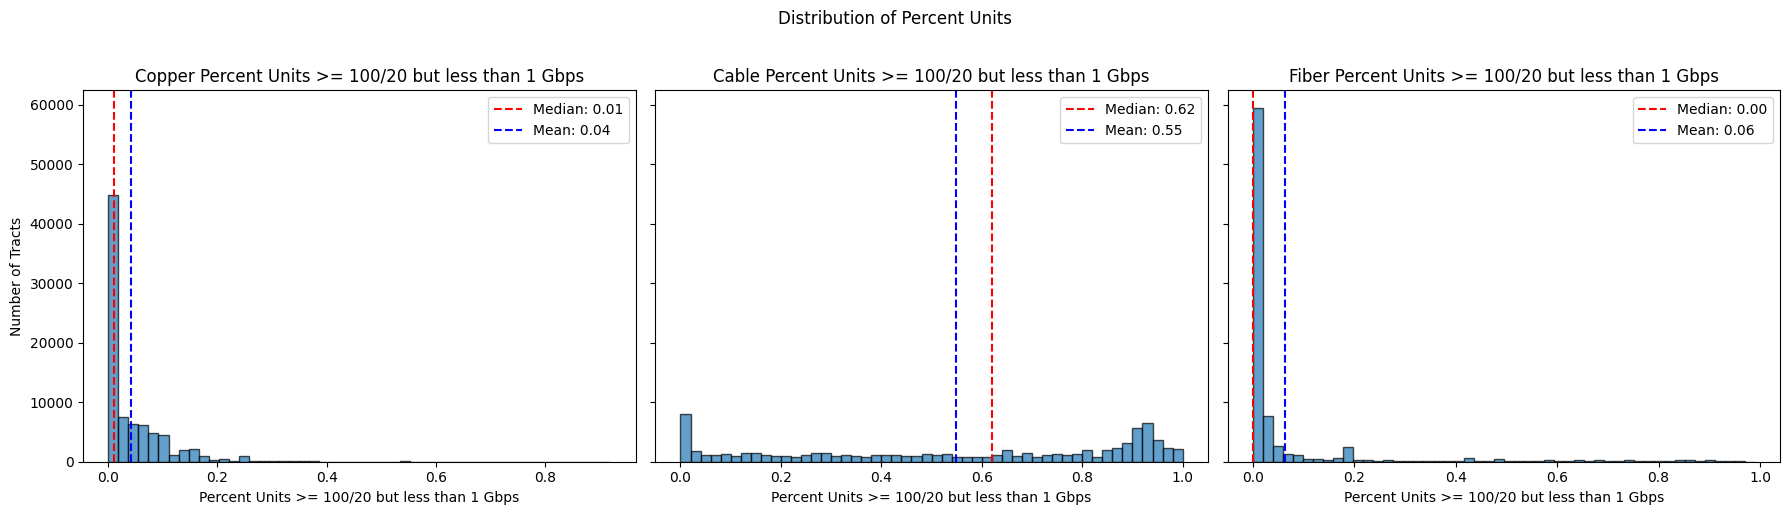

In [30]:
# Distribution of percentage speeds 100_to_sub_gig by technology
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, tech in zip(axes, ['copper', 'cable', 'fiber']):
    col = f'{tech}_speed_100_to_sub_gig'
    ax.hist(tract_df_modified[col], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(tract_df_modified[col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[col].median():.2f}')
    ax.axvline(tract_df_modified[col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.2f}')
    ax.set_title(f'{tech.title()} Percent Units >= 100/20 but less than 1 Gbps')
    ax.set_xlabel('Percent Units >= 100/20 but less than 1 Gbps')
    ax.legend()

axes[0].set_ylabel('Number of Tracts')
plt.suptitle('Distribution of Percent Units', y=1.02)
plt.tight_layout()

# Summary stats side by side
loc_cols = [f'{t}_speed_100_to_sub_gig' for t in ['copper', 'cable', 'fiber']]
print(tract_df_modified[loc_cols].describe().round(3).to_string())

       copper_speed_1000_100_only  cable_speed_1000_100_only  fiber_speed_1000_100_only
count                    83313.00                  83313.000                  83313.000
mean                         0.00                      0.274                      0.453
std                          0.01                      0.341                      0.277
min                          0.00                      0.000                      0.000
25%                          0.00                      0.000                      0.230
50%                          0.00                      0.040                      0.460
75%                          0.00                      0.570                      0.660
max                          0.93                      1.000                      1.000


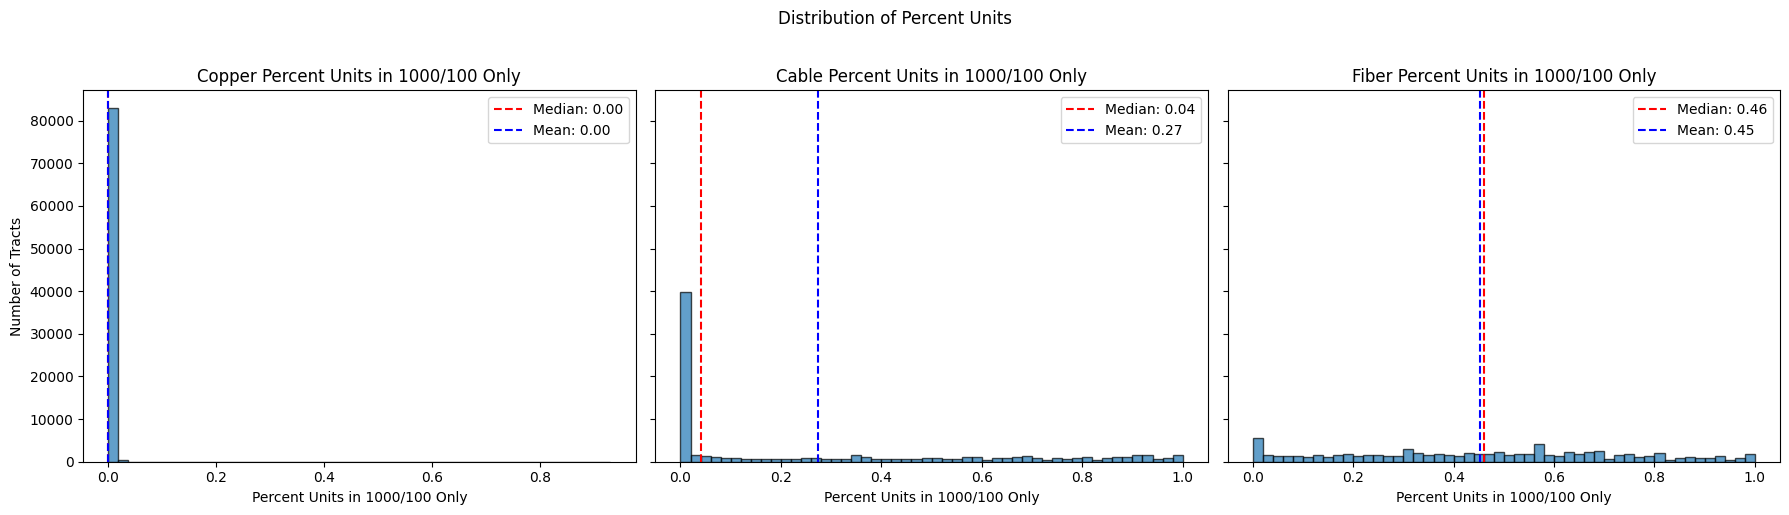

In [31]:
# Distribution of percentage speeds 1000_100 by technology
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, tech in zip(axes, ['copper', 'cable', 'fiber']):
    col = f'{tech}_speed_1000_100_only'
    ax.hist(tract_df_modified[col], bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(tract_df_modified[col].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified[col].median():.2f}')
    ax.axvline(tract_df_modified[col].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified[col].mean():.2f}')
    ax.set_title(f'{tech.title()} Percent Units in 1000/100 Only')
    ax.set_xlabel('Percent Units in 1000/100 Only')
    ax.legend()

axes[0].set_ylabel('Number of Tracts')
plt.suptitle('Distribution of Percent Units', y=1.02)
plt.tight_layout()

# Summary stats side by side
loc_cols = [f'{t}_speed_1000_100_only' for t in ['copper', 'cable', 'fiber']]
print(tract_df_modified[loc_cols].describe().round(3).to_string())

In [32]:
# Check correlations between the two speed features for each technology
speed_cols_100_to_sub_gig = [f'{t}_speed_100_to_sub_gig' for t in ['copper', 'cable', 'fiber']]
speed_cols_1000_100_only = [f'{t}_speed_1000_100_only' for t in ['copper', 'cable', 'fiber']]
correlation_matrix = tract_df_modified[speed_cols_100_to_sub_gig + speed_cols_1000_100_only].corr().round(2)
print("Correlation Matrix between Speed Features:")
print(correlation_matrix.to_string())

Correlation Matrix between Speed Features:
                             copper_speed_100_to_sub_gig  cable_speed_100_to_sub_gig  fiber_speed_100_to_sub_gig  copper_speed_1000_100_only  cable_speed_1000_100_only  fiber_speed_1000_100_only
copper_speed_100_to_sub_gig                         1.00                       -0.03                       -0.20                        0.02                       0.11                      -0.01
cable_speed_100_to_sub_gig                         -0.03                        1.00                       -0.02                       -0.01                      -0.76                       0.03
fiber_speed_100_to_sub_gig                         -0.20                       -0.02                        1.00                       -0.01                       0.13                      -0.32
copper_speed_1000_100_only                          0.02                       -0.01                       -0.01                        1.00                       0.01          

**Key Takeaways:**
1. % units for cable are higher in less than 1 Gbps category; the opposite is true for fiber
1. *cable_speed_100_to_sub_gig* and *cable_speed_1000_100_only* are correlated, so just retaining the former
2. *fiber_speed_100_to_sub_gig* doesn't matter as much given the values in *fiber_speed_1000_100_only*; so we'll retain the latter

**Note on zeroes in this case:**
Zeroes could be because no units fall in this speed category, or because fiber doesn't exist at all. To capture this, we can create an interaction term:
*fiber_speed_signal* = has_fiber * fiber_pct_speed_category
(where has_fiber will be zero if fiber_locations = 0 or fiber_providers = 0)

**Feature Ideas:**
1. fiber_speed_top_tier = fiber_speed_1000_100_only  * has_fiber
2. cable_future_gap = 1 - cable_pct_1000_100

**Interaction Terms:**
1. Update fiber_opportunity_gap to fiber_opportunity_score = fiber_opportunity_gap * cable_penetration * (1 + cable_future_gap)
    * fiber_opportunity_gap: share of housing units without fiber serviceability (high = lots of unfibered homes)
    * cable_penetration: share of housing units with cable serviceability (high = deployable area, infrastructure exists)
    * (1 + cable_future_gap): a boost applied when cable can't deliver gigabit
    * The full sentence: "There are lots of unfibered homes (fiber gap), in an area we know is buildable because cable made it there (cable penetration), and the cable that's there can't deliver gigabit so customers will be receptive to fiber's pitch (future gap boost)." Multiplying cable_penetration with gap doesn't cancel out — it stacks two different signals. The penetration says "deployable terrain exists." The future_gap says "and the existing service is vulnerable." Both being high is the strongest case for an overbuilder.

2. TBD because similar to point 1: upgrade_pull_future = cable_future_gap * (1 - fiber_penetration)
    * cable_future_gap: cable exists but can't deliver gigabit (high = cable is behind)
    * (1 - fiber_penetration): share of housing units without fiber (high = no fiber alternative)
    * The sentence: "Cable is the dominant option here but it's not gigabit-capable, AND customers don't have a fiber alternative to switch to. These are markets with pent-up demand for higher-quality service that nobody's currently meeting."
    * The strategic story: an overbuilder entering this market is filling a real gap — the customers who want gigabit literally have no option today.

3. TBD: growth * fiber_opportunity_gap

In [33]:
# Sanity check: tracts where fiber_location_count and fiber_provider_count disagree on zero
fiber_loc_zero_prov_not = (tract_df_modified['fiber_location_count'] == 0) & (tract_df_modified['fiber_provider_count'] > 0)
fiber_prov_zero_loc_not = (tract_df_modified['fiber_provider_count'] == 0) & (tract_df_modified['fiber_location_count'] > 0)
print(f"Fiber locations=0 but providers>0: {fiber_loc_zero_prov_not.sum()}")
print(f"Fiber providers=0 but locations>0: {fiber_prov_zero_loc_not.sum()}")

Fiber locations=0 but providers>0: 0
Fiber providers=0 but locations>0: 0


In [34]:
# has_fiber: 1 if both fiber_location_count > 0 and fiber_provider_count > 0
tract_df_modified['has_fiber'] = ((tract_df_modified['fiber_location_count'] > 0) & (tract_df_modified['fiber_provider_count'] > 0)).astype(int)
print(f"has_fiber=1: {tract_df_modified['has_fiber'].sum()}, has_fiber=0: {(tract_df_modified['has_fiber'] == 0).sum()}")


has_fiber=1: 80707, has_fiber=0: 2606


fiber_speed_top_tier stats:
count    83313.0000
mean         0.4487
std          0.2813
min          0.0000
25%          0.2200
50%          0.4600
75%          0.6600
max          1.0000
  P10: 0.0300
  P25: 0.2200
  P50: 0.4600
  P75: 0.6600
  P90: 0.8300
  P95: 0.9200
  P99: 1.0000


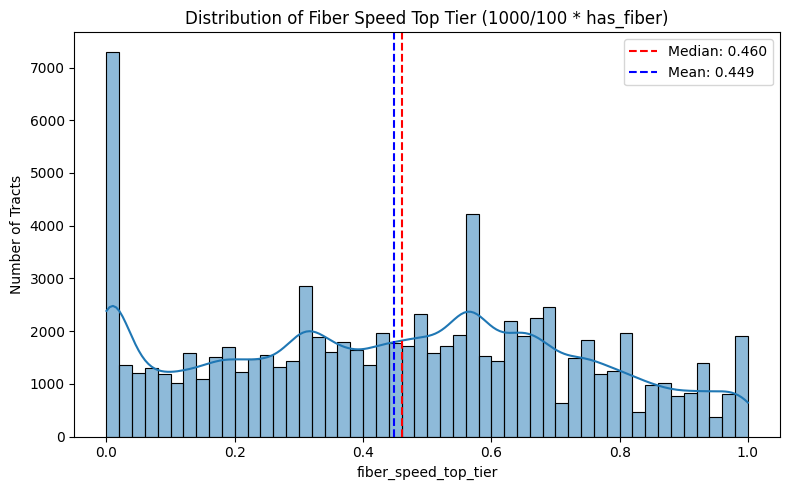

In [35]:
# fiber_speed_top_tier
tract_df_modified['fiber_speed_top_tier'] = tract_df_modified['fiber_speed_1000_100_only'] * tract_df_modified['has_fiber']

print("=" * 80)
print("fiber_speed_top_tier stats:")
print(tract_df_modified['fiber_speed_top_tier'].describe().round(4).to_string())
for p in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  P{int(p*100):02d}: {tract_df_modified['fiber_speed_top_tier'].quantile(p):.4f}")

plt.figure(figsize=(8, 5))
sns.histplot(tract_df_modified['fiber_speed_top_tier'], bins=50, kde=True)
plt.title('Distribution of Fiber Speed Top Tier (1000/100 * has_fiber)')
plt.xlabel('fiber_speed_top_tier')
plt.ylabel('Number of Tracts')
plt.axvline(tract_df_modified['fiber_speed_top_tier'].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified["fiber_speed_top_tier"].median():.3f}')
plt.axvline(tract_df_modified['fiber_speed_top_tier'].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified["fiber_speed_top_tier"].mean():.3f}')
plt.legend()
plt.tight_layout()

cable_future_gap stats:
count    83313.000
mean         0.726
std          0.341
min          0.000
25%          0.430
50%          0.960
75%          1.000
max          1.000
  P10: 0.1400
  P25: 0.4300
  P50: 0.9600
  P75: 1.0000
  P90: 1.0000
  P95: 1.0000
  P99: 1.0000


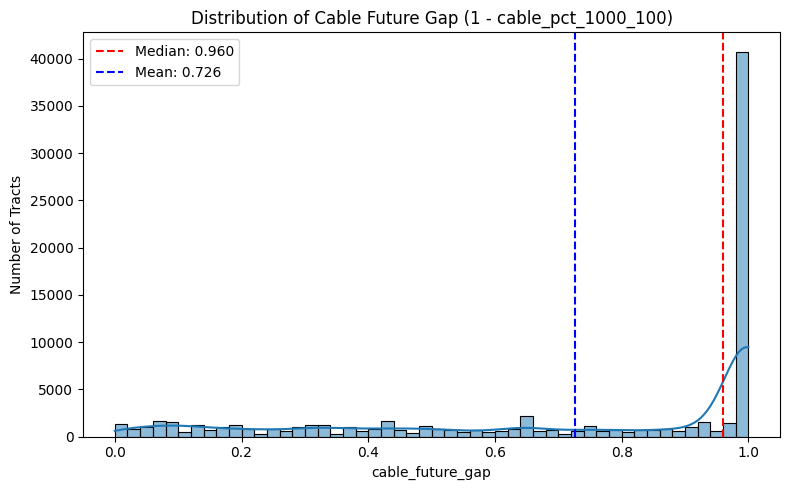

In [36]:
# cable_future_gap: 1 - cable_pct_1000_100
tract_df_modified['cable_future_gap'] = 1 - tract_df_modified['cable_speed_1000_100_only']

print("cable_future_gap stats:")
print(tract_df_modified['cable_future_gap'].describe().round(4).to_string())
for p in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  P{int(p*100):02d}: {tract_df_modified['cable_future_gap'].quantile(p):.4f}")

plt.figure(figsize=(8, 5))
sns.histplot(tract_df_modified['cable_future_gap'], bins=50, kde=True)
plt.title('Distribution of Cable Future Gap (1 - cable_pct_1000_100)')
plt.xlabel('cable_future_gap')
plt.ylabel('Number of Tracts')
plt.axvline(tract_df_modified['cable_future_gap'].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified["cable_future_gap"].median():.3f}')
plt.axvline(tract_df_modified['cable_future_gap'].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified["cable_future_gap"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

fiber_opportunity_score stats:
count    83238.0000
mean         0.5527
std          0.5574
min        -44.1661
25%          0.2009
50%          0.4245
75%          0.8052
max          3.4898
  P10: 0.0229
  P25: 0.2009
  P50: 0.4245
  P75: 0.8052
  P90: 1.3280
  P95: 1.5996
  P99: 1.9514


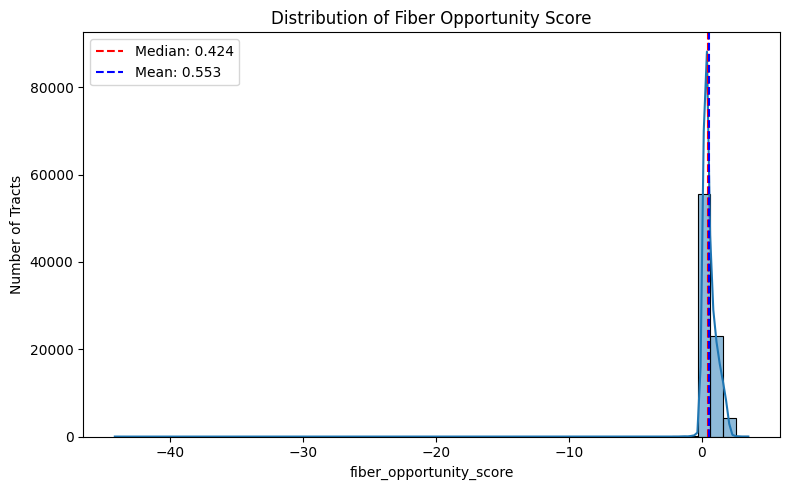

In [37]:
# fiber_opportunity_score = fiber_opportunity_gap * cable_penetration * (1 + cable_future_gap)
# fiber_opportunity_gap and cable_penetration were already computed earlier
tract_df_modified['fiber_opportunity_score'] = (
    tract_df_modified['fiber_opportunity_gap'] *
    tract_df_modified['cable_penetration'] *
    (1 + tract_df_modified['cable_future_gap'])
)

print("fiber_opportunity_score stats:")
print(tract_df_modified['fiber_opportunity_score'].describe().round(4).to_string())
for p in [0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]:
    print(f"  P{int(p*100):02d}: {tract_df_modified['fiber_opportunity_score'].quantile(p):.4f}")

plt.figure(figsize=(8, 5))
sns.histplot(tract_df_modified['fiber_opportunity_score'], bins=50, kde=True)
plt.title('Distribution of Fiber Opportunity Score')
plt.xlabel('fiber_opportunity_score')
plt.ylabel('Number of Tracts')
plt.axvline(tract_df_modified['fiber_opportunity_score'].median(), color='red', linestyle='--', label=f'Median: {tract_df_modified["fiber_opportunity_score"].median():.3f}')
plt.axvline(tract_df_modified['fiber_opportunity_score'].mean(), color='blue', linestyle='--', label=f'Mean: {tract_df_modified["fiber_opportunity_score"].mean():.3f}')
plt.legend()
plt.tight_layout()
plt.show()

Correlation matrix (fiber_opportunity_score vs components):
                         fiber_opportunity_gap  fiber_cable_interaction  cable_penetration  cable_future_gap  fiber_opportunity_score
fiber_opportunity_gap                     1.00                     0.67              -0.25             -0.06                     0.65
fiber_cable_interaction                   0.67                     1.00               0.30             -0.09                     0.97
cable_penetration                        -0.25                     0.30               1.00             -0.08                     0.29
cable_future_gap                         -0.06                    -0.09              -0.08              1.00                     0.11
fiber_opportunity_score                   0.65                     0.97               0.29              0.11                     1.00


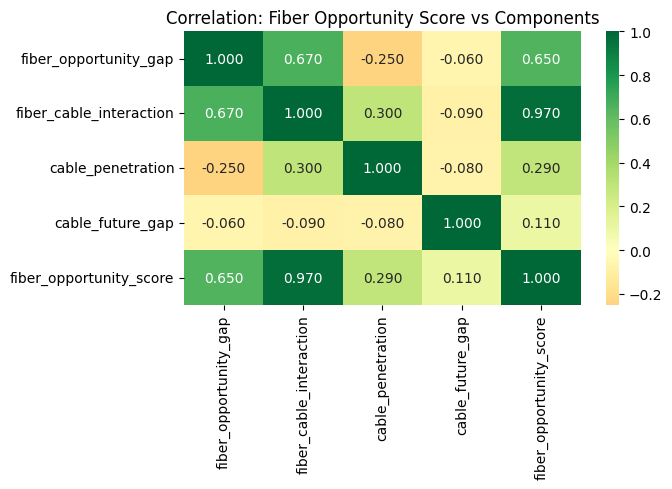

In [38]:
# Correlation with underlying interaction terms
score_components = [
    'fiber_opportunity_gap',
    'fiber_cable_interaction',
    'cable_penetration',
    'cable_future_gap',
    'fiber_opportunity_score'
]
corr = tract_df_modified[score_components].corr(method='spearman').round(2)
print("=" * 80)
print("Correlation matrix (fiber_opportunity_score vs components):")
print(corr.to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Correlation: Fiber Opportunity Score vs Components')
plt.tight_layout()
plt.show()

In [39]:
# Final dataframe ready for correlation analysis and modeling
tract_df_modified.info()

<class 'pandas.DataFrame'>
Index: 83313 entries, 0 to 85480
Data columns (total 48 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   tract_geoid                                 83313 non-null  str    
 1   pop_ch_1yr                                  83313 non-null  float64
 2   pop_ch_avg                                  83313 non-null  float64
 3   pop_pctch_1yr                               83313 non-null  float64
 4   pop_pctch_avg                               83313 non-null  float64
 5   estimated_census_housing_units              83313 non-null  int64  
 6   estimated_fcc_units                         83313 non-null  int64  
 7   copper_speed_1000_100_only                  83313 non-null  float64
 8   cable_speed_1000_100_only                   83313 non-null  float64
 9   fiber_speed_1000_100_only                   83313 non-null  float64
 10  cable_location_count      

In [40]:
# Columns to drop based on analysis above and to avoid redundancy in correlation analysis
cols_to_drop_for_corr = [
    # Providers
    'copper_provider_count',
    'cable_provider_count',
    'fiber_provider_count',
    'fiber_provider_density_per_1000_hhs', # Created a capped feature
    'log1p_fiber_provider_density_per_1000_hhs', # Removing because fiber_provider_density_per_1000_hhs = exp(log1p_fiber_provider_density_per_1000_hhs) - 1
    
    # Locations
    'copper_location_count', 
    'cable_location_count',
    'fiber_location_count',
    'fiber_penetration', # Captured by fiber opportunity gap
    
    # Speeds
    'copper_max_download_speed',
    #'cable_max_download_speed', # Can remove this later
    'cable_max_upload_speed',
    #'fiber_max_download_speed', 
    'fiber_max_upload_speed', # Can remove this later

    # % Residential units in different speed tiers
    'has_fiber', # Removing because it is reflected in fiber_penetration and fiber_provider_density
    'copper_speed_100_to_sub_gig',
    'copper_speed_1000_100_only',
    'cable_speed_100_to_sub_gig',
    'cable_speed_1000_100_only', # Removing because cable_future_gap = 1 - cable_speed_1000_100_only
    'fiber_speed_100_to_sub_gig', # Not taking into account
    'fiber_speed_1000_100_only', # Removing because fiber_speed_top_tier = has_fiber * fiber_speed_1000_100_only

    # Others
    'fiber_opportunity_score', # Captured in fiber_cable_interaction
]

corr_df = tract_df_modified.drop(columns=cols_to_drop_for_corr)
print(f"Total columns in tract_df: {tract_df_modified.shape[1]}, columns dropped for correlation analysis: {len(cols_to_drop_for_corr)}, columns in corr_df: {corr_df.shape[1]}")
corr_df.info()

Total columns in tract_df: 48, columns dropped for correlation analysis: 20, columns in corr_df: 28
<class 'pandas.DataFrame'>
Index: 83313 entries, 0 to 85480
Data columns (total 28 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   tract_geoid                                 83313 non-null  str    
 1   pop_ch_1yr                                  83313 non-null  float64
 2   pop_ch_avg                                  83313 non-null  float64
 3   pop_pctch_1yr                               83313 non-null  float64
 4   pop_pctch_avg                               83313 non-null  float64
 5   estimated_census_housing_units              83313 non-null  int64  
 6   estimated_fcc_units                         83313 non-null  int64  
 7   cable_max_download_speed                    80620 non-null  float64
 8   fiber_max_download_speed                    80707 non-null  float64
 9  

In [41]:
# Add ordinal encoding for provider_competitive_landscape to include in correlation analysis
landscape_order = {
    'no_providers': 0,
    'greenfield': 1,
    'cable_but_no_fiber': 2,
    'fiber_entry': 3,
    'fiber_duopoly': 4,
    'fiber_competitive': 5,
    'fiber_saturated': 6
}
corr_df['provider_competitive_landscape_ord'] = corr_df['provider_competitive_landscape'].map(landscape_order)
corr_df['provider_competitive_landscape_ord'].value_counts()
corr_df.info()

<class 'pandas.DataFrame'>
Index: 83313 entries, 0 to 85480
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   tract_geoid                                 83313 non-null  str    
 1   pop_ch_1yr                                  83313 non-null  float64
 2   pop_ch_avg                                  83313 non-null  float64
 3   pop_pctch_1yr                               83313 non-null  float64
 4   pop_pctch_avg                               83313 non-null  float64
 5   estimated_census_housing_units              83313 non-null  int64  
 6   estimated_fcc_units                         83313 non-null  int64  
 7   cable_max_download_speed                    80620 non-null  float64
 8   fiber_max_download_speed                    80707 non-null  float64
 9   pre_early_dev_parcels                       83216 non-null  float64
 10  builder_developer_count   

In [42]:
# This dataframe should be saved in teu_analytics dataset in BQ
if NETWORK_IDX_ENV == "local":
    check_and_authenticate(GCS_ADC_JSON_PATH_EP_LOCAL)

client = bigquery.Client(project=GCS_PROJECT_ID)
table_id = f"{GCS_PROJECT_ID}.teu_analytics.fcc_feature_engg_tract"

job_config = bigquery.LoadJobConfig(
    write_disposition=bigquery.WriteDisposition.WRITE_TRUNCATE,
)

job = client.load_table_from_dataframe(corr_df, table_id, job_config=job_config)
job.result()

print(f"Uploaded {job.output_rows} rows to {table_id}")

Error: Credentials file not found


/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/_pandas_helpers.py:486: FutureWarning: Loading pandas DataFrame into BigQuery will require pandas-gbq package version 0.26.1 or greater in the future. Tried to import pandas-gbq and got: No module named 'pandas_gbq'
  warnings.warn(


Uploaded 83313 rows to clgx-gis-app-dev-06e3.teu_analytics.fcc_feature_engg_tract
